In [1]:
## This is a tutorial for posterior processing.

# If you would like to use getdist-gui, run the following code.
# ! getdist-gui

# Following are some typical usages of the loadMCSamples/load_samples packages

<Figure size 1200x400 with 0 Axes>

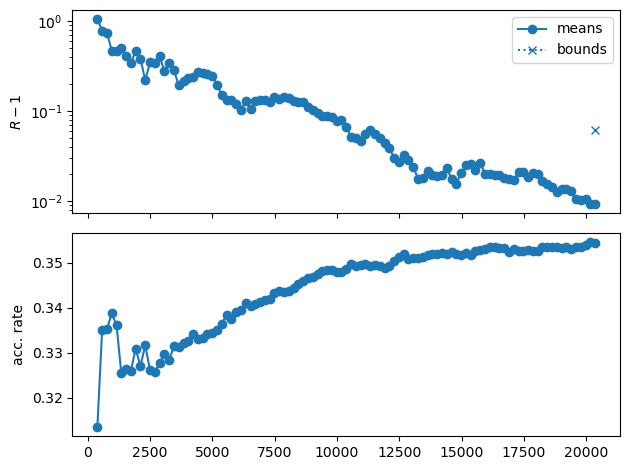

Number of samples after burn-in skip: 17808
chains/CMB+DESI_LCDM H_0 = 67.89\pm 0.37 \Omega_\mathrm{m0} = 0.3064\pm 0.0049 \sigma_8 = 0.8065\pm 0.0055 S_8 = 0.8151\pm 0.0090
Best fit sample -log(Like) = 5494.772200
Ln(mean 1/like) = 5509.183266
mean(-Ln(like)) = 5501.318354
-Ln(mean like)  = 5499.005890
2*Var(Ln(like)) = 15.505658

parameter                                 bestfit        lower1         upper1         lower2         upper2
logA                                      3.0437673E+00  3.0011570E+00  3.0882305E+00  2.9946922E+00  3.0973440E+00   \log(10^{10} A_\mathrm{s})
ns                                        9.6732683E-01  9.5401916E-01  9.7788835E-01  9.5352327E-01  9.7880000E-01   n_\mathrm{s}
theta_MC_100                              1.0412993E+00  1.0404120E+00  1.0418226E+00  1.0402437E+00  1.0419753E+00   100\theta_\mathrm{MC}
ombh2                                     2.2237083E-02  2.1859528E-02  2.2656716E-02  2.1774382E-02  2.2710457E-02   \Omega_\mathrm{b} h^2
o

<Figure size 1200x400 with 0 Axes>

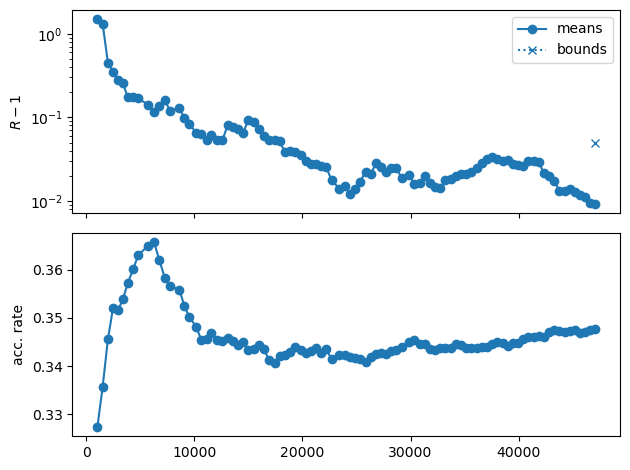

Number of samples after burn-in skip: 32956
chains2/CMB+DESI_LCDM H_0 = 67.86\pm 0.37 \Omega_\mathrm{m0} = 0.3067\pm 0.0049 \sigma_8 = 0.8066\pm 0.0056 S_8 = 0.8156\pm 0.0091
Best fit sample -log(Like) = 5495.061300
Ln(mean 1/like) = 5511.591060
mean(-Ln(like)) = 5501.361029
-Ln(mean like)  = 5498.954921
2*Var(Ln(like)) = 16.447890

parameter                                 bestfit        lower1         upper1         lower2         upper2
logA                                      3.0414489E+00  3.0039827E+00  3.0876005E+00  2.9964845E+00  3.0983726E+00   \log(10^{10} A_\mathrm{s})
ns                                        9.6508288E-01  9.5539856E-01  9.7835464E-01  9.5366879E-01  9.7962645E-01   n_\mathrm{s}
theta_MC_100                              1.0412183E+00  1.0403605E+00  1.0419071E+00  1.0403160E+00  1.0419703E+00   100\theta_\mathrm{MC}
ombh2                                     2.2239270E-02  2.1867322E-02  2.2647023E-02  2.1819984E-02  2.2760665E-02   \Omega_\mathrm{b} h^2


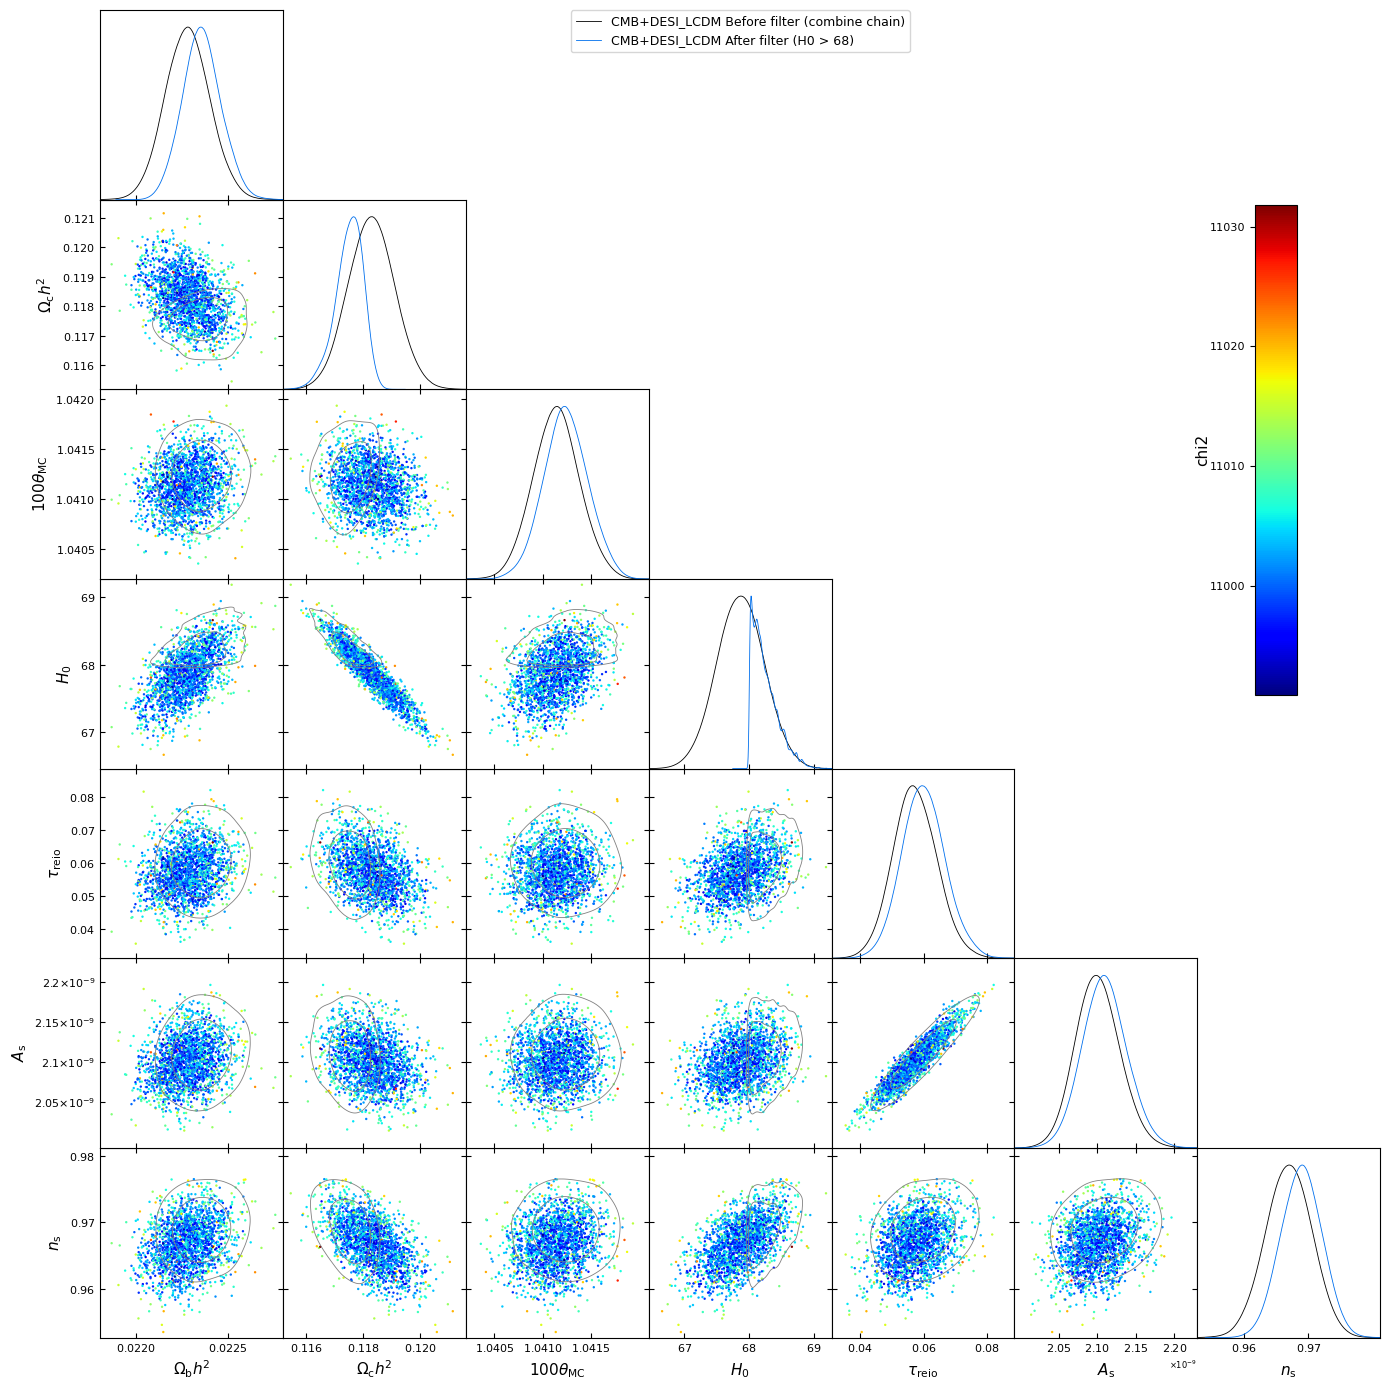

In [2]:
from getdist import plots
from cobaya import load_samples
from cobaya.samplers.mcmc import plot_progress
import matplotlib.pyplot as plt
import numpy as np
from getdist.mcsamples import MCSamples

def get_samples(root, **kwargs):
    combined = kwargs.get('combined', False)
    skip = kwargs.get('skip')
    get_prog = kwargs.get('get_prog')
    get_like = kwargs.get('get_like')
    get_band = kwargs.get('get_band')
    get_conv = kwargs.get('get_conv')

    if get_prog:
        plt.figure(figsize=(12, 4))
        plot_progress(chains_root + root[0])
        plt.tight_layout()
        plt.show() 

    # Load first chain
    samples1 = load_samples(chains_root + root[0], skip=skip, to_getdist=True, combined=combined)
    p1 = samples1.getParams()
    samples1.addDerived(p1.s8omegamp5 * 0.3**-0.5, 'S8', label=r'S_8')
    
    print('Number of samples after burn-in skip: ' + str(len(samples1.getParams().H0)))
    print(chains_root + root[0],
          samples1.getInlineLatex('H0'),
          samples1.getInlineLatex('omegam'),
          samples1.getInlineLatex('sigma8'),
          samples1.getInlineLatex('S8'))
    
    if get_like: print(samples1.getLikeStats())
    if get_band: print(samples1.getMargeStats())
    if get_conv: print(samples1.getConvergeTests()) 

    # No second chain
    if root[1] is None:
        raw_samples = samples1
    # Load and combine second chain
    else:  
        if get_prog:
            plt.figure(figsize=(12, 4))
            plot_progress(chains_root2 + root[1])
            plt.tight_layout()
            plt.show()   
        
        samples2 = load_samples(chains_root2 + root[1], skip=skip, to_getdist=True, combined=combined)
        p2 = samples2.getParams()
        samples2.addDerived(p2.s8omegamp5 * 0.3**-0.5, 'S8', label=r'S_8')
        
        print('Number of samples after burn-in skip: ' + str(len(samples2.getParams().H0)))
        print(chains_root2 + root[1],
              samples2.getInlineLatex('H0'),
              samples2.getInlineLatex('omegam'),
              samples2.getInlineLatex('sigma8'),
              samples2.getInlineLatex('S8'))
        
        if get_like: print(samples2.getLikeStats())
        if get_band: print(samples2.getMargeStats())
        if get_conv: print(samples2.getConvergeTests()) 

        # Combine chains
        raw_samples = MCSamples(
            samples=np.concatenate([samples1.samples, samples2.samples]),
            weights=np.concatenate([samples1.weights, samples2.weights]),
            loglikes=np.concatenate([samples1.loglikes, samples2.loglikes]),
            names=[n.name for n in samples1.getParamNames().names],
            labels=[n.label for n in samples1.getParamNames().names]
        )
        
        print('Combined chain: ',
              raw_samples.getInlineLatex('H0'),
              raw_samples.getInlineLatex('omegam'),
              raw_samples.getInlineLatex('sigma8'),
              raw_samples.getInlineLatex('S8'))
        
        if get_like: print(raw_samples.getLikeStats())
        if get_band: print(raw_samples.getMargeStats())
        if get_conv: print(raw_samples.getConvergeTests())         

    # Filter H0 > 68 
    H0_vals = raw_samples.getParams().H0
    filtered_samples = raw_samples.copy()
    filtered_samples.filter(H0_vals > 68)

    print("\n" + "="*50)
    print(f"Total raw samples: {len(raw_samples.getParams().H0)}")
    print(f"Filtered samples (H0 > 68): {len(filtered_samples.getParams().H0)}")
    print(f"Removed {len(raw_samples.getParams().H0) - len(filtered_samples.getParams().H0)} samples")
    print("="*50 + "\n")
    
    print("Filtered chain results:")
    print(filtered_samples.getInlineLatex('H0'),
          filtered_samples.getInlineLatex('omegam'),
          filtered_samples.getInlineLatex('sigma8'),
          filtered_samples.getInlineLatex('S8'))
    if get_like: print(filtered_samples.getLikeStats())
    if get_band: print(filtered_samples.getMargeStats())
    if get_conv: print(filtered_samples.getConvergeTests())  


    
    return raw_samples, filtered_samples

# Paths
chains_root = 'chains/'
chains_root2 = 'chains2/'

# Load chains
CMB_DESI_LCDM, CMB_DESI_filtered = get_samples(['CMB+DESI_LCDM','CMB+DESI_LCDM'],
                                       get_prog=True, get_band=True, skip=0.3, get_like=True)

# Plot before vs after filter comparison
g = plots.get_subplot_plotter(analysis_settings={'ignore_rows': 0.1})
params = ['ombh2','omch2','theta_MC_100','H0','tau','As','ns']
g.triangle_plot([CMB_DESI_LCDM, CMB_DESI_filtered],
                params,
                filled=[False, True],
                legend_labels=["CMB+DESI_LCDM Before filter (combine chain)", "CMB+DESI_LCDM After filter (H0 > 68)"],
                colors=["#808080", "#1f77b4"],
                alpha_filled=0.6,
                plot_3d_with_param='chi2')
plt.show()

In [3]:
CMB_DESI_PPS_LCDM, CMB_DESI_PPS_LCDM_filtered = get_samples(['CMB+DESI+PPS_LCDM','CMB+DESI+PPS_LCDM'],
                                       get_prog=False, get_band=False, skip=0.3, get_like=False)

Number of samples after burn-in skip: 35448
chains/CMB+DESI+PPS_LCDM H_0 = 68.40\pm 0.34 \Omega_\mathrm{m0} = 0.2999\pm 0.0044 \sigma_8 = 0.8060\pm 0.0059 S_8 = 0.8058\pm 0.0088
Number of samples after burn-in skip: 48932
chains2/CMB+DESI+PPS_LCDM H_0 = 68.40\pm 0.33 \Omega_\mathrm{m0} = 0.2998\pm 0.0043 \sigma_8 = 0.8060\pm 0.0058 S_8 = 0.8057\pm 0.0086
Combined chain:  H_0 = 68.40\pm 0.34 \Omega_\mathrm{m0} = 0.2998\pm 0.0044 \sigma_8 = 0.8060\pm 0.0058 S_8 = 0.8058\pm 0.0087

Total raw samples: 84380
Filtered samples (H0 > 68): 74219
Removed 10161 samples

Filtered chain results:
H_0 = 68.40\pm 0.34 \Omega_\mathrm{m0} = 0.2998\pm 0.0044 \sigma_8 = 0.8060\pm 0.0058 S_8 = 0.8058\pm 0.0087


In [4]:
CMB_LCDM, CMB_LCDM_filtered = get_samples(['CMB_LCDM',None],
                                       get_prog=False, get_band=False, skip=0.3, get_like=False)

Number of samples after burn-in skip: 26880
chains/CMB_LCDM H_0 = 67.22\pm 0.45 \Omega_\mathrm{m0} = 0.3156\pm 0.0062 \sigma_8 = 0.8077\pm 0.0055 S_8 = 0.828\pm 0.011

Total raw samples: 26880
Filtered samples (H0 > 68): 1115
Removed 25765 samples

Filtered chain results:
H_0 = 67.22\pm 0.45 \Omega_\mathrm{m0} = 0.3156\pm 0.0062 \sigma_8 = 0.8077\pm 0.0055 S_8 = 0.828\pm 0.011


In [5]:
DESI_LCDM, DESI_LCDM_filtered = get_samples(['DESI_LCDM','DESI_LCDM'],
                                       get_prog=False, get_band=False, skip=0.3, get_like=False)

Number of samples after burn-in skip: 8176


chains/DESI_LCDM H_0 = 68.70\pm 0.79 \Omega_\mathrm{m0} = 0.295\pm 0.015 \sigma_8 = 0.73^{+0.14}_{-0.33} S_8 = 0.73^{+0.15}_{-0.33}
Number of samples after burn-in skip: 39764


chains2/DESI_LCDM H_0 = 68.72\pm 0.79 \Omega_\mathrm{m0} = 0.295^{+0.013}_{-0.016} \sigma_8 = 0.69^{+0.12}_{-0.30} S_8 = 0.68^{+0.12}_{-0.30}
Combined chain:  H_0 = 68.72\pm 0.79 \Omega_\mathrm{m0} = 0.295^{+0.014}_{-0.016} \sigma_8 = 0.70^{+0.12}_{-0.31} S_8 = 0.69^{+0.12}_{-0.31}

Total raw samples: 47940
Filtered samples (H0 > 68): 39249
Removed 8691 samples

Filtered chain results:
H_0 = 68.72\pm 0.79 \Omega_\mathrm{m0} = 0.295^{+0.014}_{-0.016} \sigma_8 = 0.70^{+0.12}_{-0.31} S_8 = 0.69^{+0.12}_{-0.31}


In [6]:
PPS_LCDM, PPS_LCDM_filtered = get_samples(['PPS_LCDM','PPS_LCDM'],
                                       get_prog=False, get_band=False, skip=0.3, get_like=False)

Number of samples after burn-in skip: 32256


chains/PPS_LCDM H_0 = 73.6\pm 1.0 \Omega_\mathrm{m0} = 0.332\pm 0.018 \sigma_8 = 0.91^{+0.19}_{-0.42} S_8 = 0.96^{+0.20}_{-0.44}
Number of samples after burn-in skip: 9125
chains2/PPS_LCDM H_0 = 73.5\pm 1.0 \Omega_\mathrm{m0} = 0.332\pm 0.018 \sigma_8 = 0.91^{+0.21}_{-0.42} S_8 = 0.96^{+0.22}_{-0.44}
Combined chain:  H_0 = 73.6\pm 1.0 \Omega_\mathrm{m0} = 0.332\pm 0.018 \sigma_8 = 0.91^{+0.19}_{-0.42} S_8 = 0.96^{+0.20}_{-0.45}

Total raw samples: 41381
Filtered samples (H0 > 68): 41381
Removed 0 samples

Filtered chain results:
H_0 = 73.6\pm 1.0 \Omega_\mathrm{m0} = 0.332\pm 0.018 \sigma_8 = 0.91^{+0.19}_{-0.42} S_8 = 0.96^{+0.20}_{-0.45}


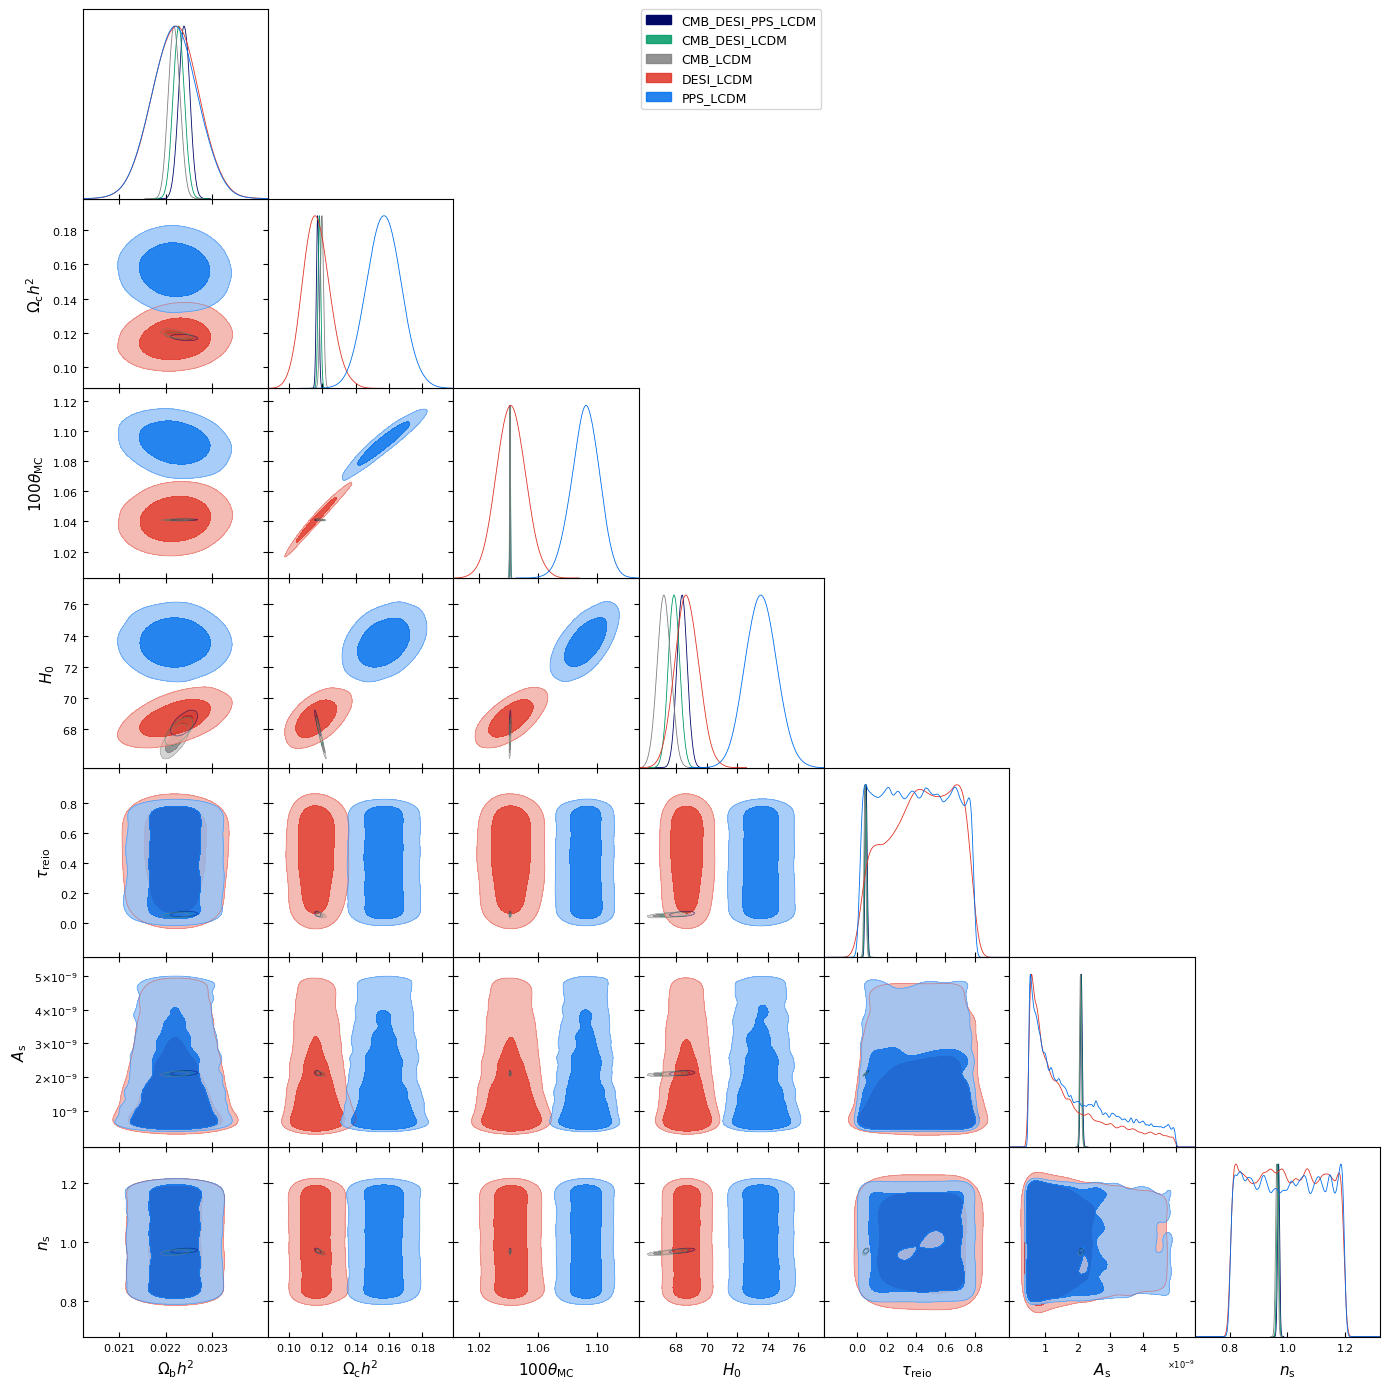

In [7]:
g = plots.get_subplot_plotter(analysis_settings={'ignore_rows': 0.1})
params = ['ombh2','omch2','theta_MC_100','H0','tau','As','ns']
g.triangle_plot([CMB_DESI_PPS_LCDM,CMB_DESI_LCDM,CMB_LCDM,DESI_LCDM,PPS_LCDM],
                legend_labels=["CMB_DESI_PPS_LCDM", "CMB_DESI_LCDM","CMB_LCDM","DESI_LCDM","PPS_LCDM"],
                params = params,
                filled=True)
plt.show()

((67.10066560726975, 69.72022539273026),
 (0.2830108903256046, 0.3171501896743954))

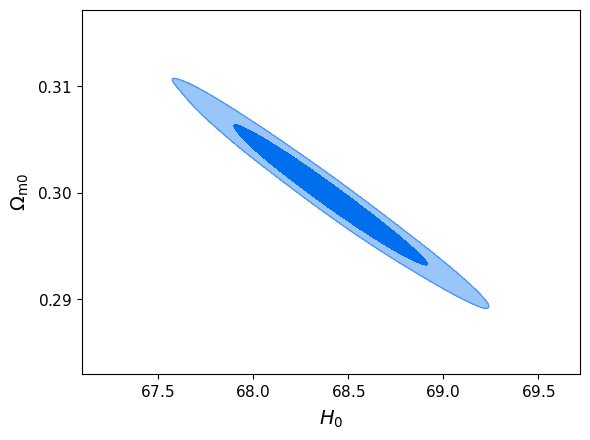

In [8]:
g = plots.get_single_plotter(analysis_settings={'ignore_rows': 0.1})

g.plot_2d([CMB_DESI_PPS_LCDM],['H0','omegam'],
                filled=True)


<Figure size 600x450 with 0 Axes>

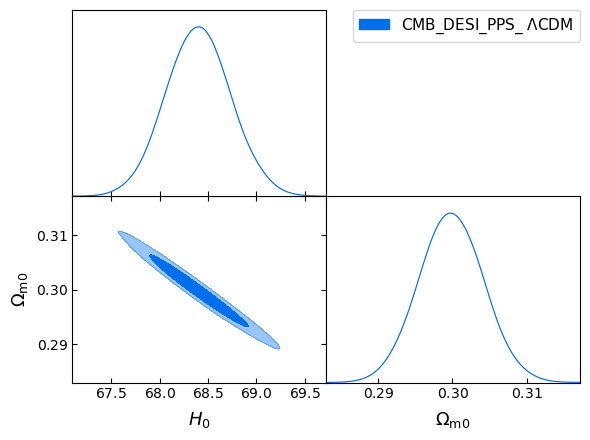

In [9]:
g = plots.get_single_plotter(analysis_settings={'ignore_rows': 0.1})
g.triangle_plot([CMB_DESI_PPS_LCDM],['H0','omegam'],
                legend_labels=[r'CMB$\_$DESI$\_$PPS$\_$ $\Lambda$CDM'],
                filled=True)

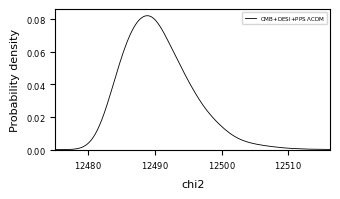

In [10]:
g=plots.get_subplot_plotter(width_inch=3.5, subplot_size_ratio=0.6)

g.settings.line_labels = False
g.settings.fontsize = 5
g.settings.legend_fontsize = 1
g.settings.linewidth = 0.3
g.settings.axes_labelsize = 5
g.settings.axes_fontsize = 6
g.settings.axes_labelsize = 8
g.settings.axis_tick_max_labels = 6
g.settings.linewidth = 0.3
g.settings.prob_y_ticks = True
g.settings.norm_prob_label = "Probability density"
g.plots_1d([CMB_DESI_PPS_LCDM], params='chi2',normalized=True,legend_ncol=3)
g.settings.line_labels = False
g.add_legend(legend_labels=[r'CMB+DESI+PPS $\Lambda$CDM'], legend_loc='upper right',fontsize=4,legend_ncol=1);


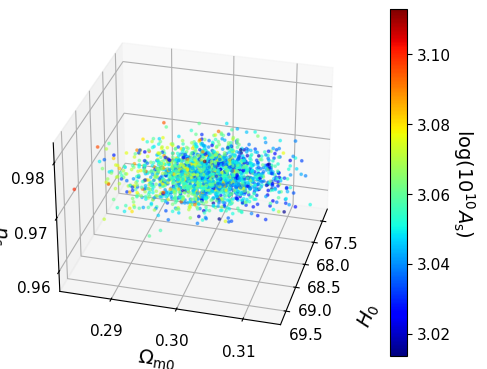

In [11]:
g=plots.get_single_plotter()
params = ['H0', 'omegam', 'ns', 'logA']
g.plot_4d([CMB_DESI_PPS_LCDM], params, color_bar=True)

In [ ]:
# CPL model with markers

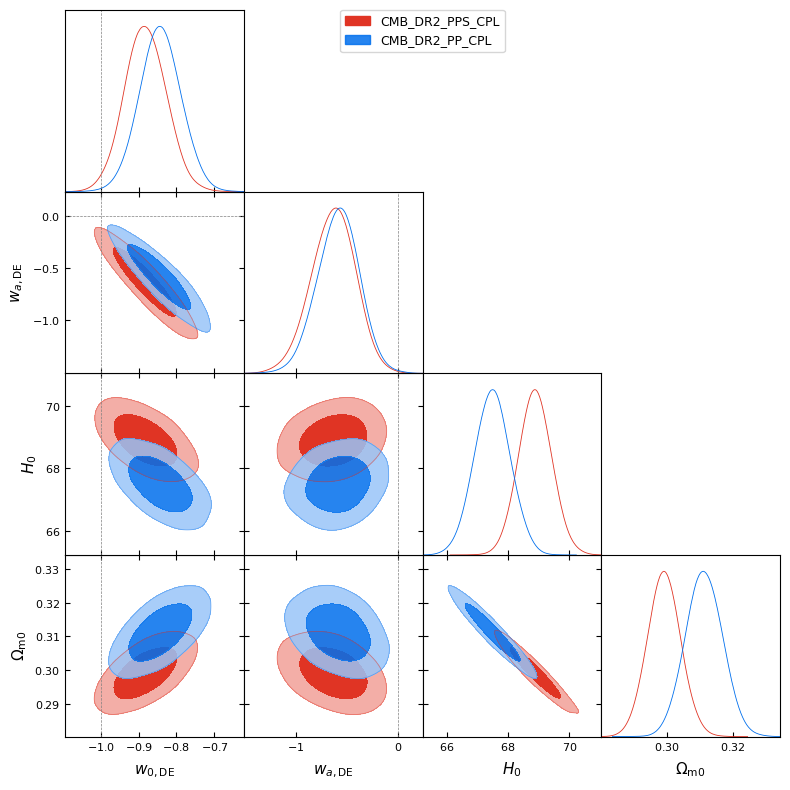

In [32]:
import os
from pathlib import Path
from getdist import plots
BASE_DIR = Path.cwd()
chain_dir = BASE_DIR / "chainsCPL"


g = plots.get_subplot_plotter(chain_dir=str(chain_dir))

roots = ['CMB_DR2_PPS_CPL', 'CMB_DR2_PP_CPL']
params = ['w', 'wa','H0','omegam']
g.triangle_plot(roots, params, markers={'w': -1,'wa':0},filled=True,)


In [12]:
#For more advanced and fancy usage examples, 
#please refer to the official documentation at https://getdist.readthedocs.io/en/latest/plots.html 
#as well as the original package source code.

In [13]:
#https://pantheonplussh0es.github.io
#https://github.com/PantheonPlusSH0ES/DataRelease

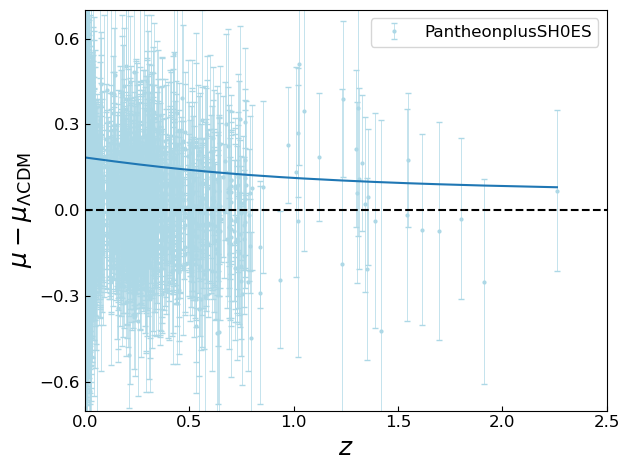

In [14]:

import numpy as np
import sys, platform, os
import matplotlib.pyplot as plt
import camb

import csv
from scipy.integrate import solve_ivp
import pandas as pd
from scipy.linalg import inv
from matplotlib.backends.backend_pdf import PdfPages

data_file ="./snedata/Pantheon+SH0ES.dat"
covmat_file = "./snedata/Pantheon+SH0ES_STAT+SYS.cov"
data = pd.read_csv(data_file, sep='\s+')
zhel=data['zHD']
##\LambdaCDM best-fit setting
pars0 = camb.set_params(ombh2 = 0.0222,
                           omch2 = 0.156528,
                           H0 = 73.6,
                           ns = 0.965,
                           tau = 0.055,
                           As = 2.1e-9,
                           M = 0,
                           mnu = 0.06 )
results0 = camb.get_results(pars0)                  
dl0 = results0.luminosity_distance(z=data['zHD'])
mu0=(5*np.log10(dl0)+25)

##tune H0=73.6 ==> H0 = 67.6
pars = camb.set_params(ombh2 = 0.0222,
                           omch2 = 0.156528,
                           H0 = 67.6,
                           ns = 0.965,
                           tau = 0.055,
                           As = 2.1e-9,
                           M = 0,
                           mnu = 0.06 )
results = camb.get_results(pars)                  
dl = results.luminosity_distance(z=data['zHD'])
mu=(5*np.log10(dl)+25)

plt.plot(zhel, mu-mu0)
    
mu_obs = data['MU_SH0ES']-mu0
mu_obs_err=data['MU_SH0ES_ERR_DIAG']
plt.errorbar(zhel, mu_obs, yerr=mu_obs_err, fmt='o',markersize=2, capsize=2, elinewidth=0.5,zorder = 0,color='lightblue', label='PantheonplusSH0ES')
plt.ylabel(r'$\mu-\mu_{\Lambda\text{CDM}}$',fontsize=18)
plt.xlabel(r'$z$',fontsize=18)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='both', direction='in',)
plt.ylim(-0.7,0.7)
plt.xlim(0.0,2.5)
plt.axhline(y = 0, linestyle='--', color='black')
plt.yticks(np.linspace(-0.6,0.6, 5),fontsize=12)
plt.xticks(np.linspace(0,2.5, 6),fontsize=12)
plt.subplots_adjust(left=0.15, right=0.9, bottom=0.15, top=0.9, wspace=0.2, hspace=0.2)
plt.tight_layout()

plt.show()